In [1]:
from pystac_client import Client
import pandas as pd
import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import xarray as xr
from distributed import LocalCluster

Setup


In [2]:
# Create local processing cluster
cluster = LocalCluster()
client = cluster.get_client()

harz_boundaries = gpd.read_file("../resources/Nationalpark_Harz_boundaries.geojson")
bbox = harz_boundaries.geometry.values[0].bounds
catalog = Client.open("https://stac.core.eopf.eodc.eu")

In [3]:
results = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime=["2024-04-30", "2025-05-01"],
)
items = results.item_collection()

sr_datasets = []

for item in items:
    # Open SR_20m asset for this item
    ds = xr.open_dataset(item.assets["SR_10m"].href, engine="eopf-zarr", chunks={}, decode_timedelta=True)

    # Expand a time dimension using the item's timestamp
    ds = ds.expand_dims(time=pd.to_datetime([item.datetime]))

    sr_datasets.append(ds)

# Combine all items into one Dataset along time
r10m = xr.concat(sr_datasets, dim="time", join="outer")
r10m

<xarray.Dataset> Size: 170GB
Dimensions:      (time: 23, y: 10980, x: 20982)
Coordinates:
  * time         (time) datetime64[ns, tzutc()] 184B 2025-04-30 10:27:01.0240...
  * y            (y) int64 88kB 5800015 5800005 5799995 ... 5690235 5690225
  * x            (x) int64 168kB 499985 499995 500005 ... 709775 709785 709795
    spatial_ref  int64 8B 0
Data variables:
    b02          (time, y, x) float64 42GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b03          (time, y, x) float64 42GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b04          (time, y, x) float64 42GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b08          (time, y, x) float64 42GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>

In [4]:
import xarray as xr
import zarr
import dask.array as da
import pandas as pd

catalog = Client.open("https://stac.core.eopf.eodc.eu")
results = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime=["2025-04-20", "2025-05-01"],
)
items = results.item_collection()

sr_datasets = []

for item in items:
    # ------------------------------------------------------------------
    # 1. Open SR_20m
    # ------------------------------------------------------------------
    ds = xr.open_dataset(
        item.assets["SR_20m"].href,
        engine="eopf-zarr",
        chunks={}
    )

    # ------------------------------------------------------------------
    # 2. Open SCL_20m as a Dask-backed DataArray
    # ------------------------------------------------------------------
    scl_z = zarr.open(item.assets["SCL_20m"].href, mode="r")
    scl_da = xr.DataArray(
        da.from_array(scl_z, chunks=scl_z.chunks),
        dims=("y", "x"),
        name="scl"
    )

    # ------------------------------------------------------------------
    # 3. Add SCL as a new variable to the dataset
    # ------------------------------------------------------------------
    ds = ds.assign(scl=scl_da)

    # ------------------------------------------------------------------
    # 4. Add time dimension consistent with SR dataset
    # ------------------------------------------------------------------
    ds = ds.expand_dims(time=[pd.to_datetime(item.datetime)])

    sr_datasets.append(ds)

# ----------------------------------------------------------------------
# 5. Combine all datasets into a single time stack
# ----------------------------------------------------------------------
r20m_mask_l2a_classification = xr.concat(sr_datasets, dim="time", join="outer")
r20m_mask_l2a_classification

<xarray.Dataset> Size: 48GB
Dimensions:      (time: 10, y: 5490, x: 10491)
Coordinates:
  * time         (time) datetime64[ns, tzutc()] 80B 2025-04-30 10:27:01.02400...
  * y            (y) int64 44kB 5800010 5799990 5799970 ... 5690250 5690230
  * x            (x) int64 84kB 499990 500010 500030 ... 709750 709770 709790
    spatial_ref  int64 8B 0
Data variables:
    b01          (time, y, x) float64 5GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b02          (time, y, x) float64 5GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b03          (time, y, x) float64 5GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b04          (time, y, x) float64 5GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b05          (time, y, x) float64 5GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b06          (time, y, x) float64 5GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b07          (time, y, x) float64 5GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b11          (time, y, x) float64 5GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b12          (time, y, x) float64 5GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b8a          (time, y, x) float64 5GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    scl          (time, y, x) float32 2GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>

In [5]:
factor = 10
r100m = r10m.coarsen(x=factor, y=factor, boundary="trim").mean()
r100m

<xarray.Dataset> Size: 2GB
Dimensions:      (time: 23, y: 1098, x: 2098)
Coordinates:
  * time         (time) datetime64[ns, tzutc()] 184B 2025-04-30 10:27:01.0240...
  * y            (y) float64 9kB 5.8e+06 5.8e+06 5.8e+06 ... 5.69e+06 5.69e+06
  * x            (x) float64 17kB 5e+05 5.001e+05 ... 7.096e+05 7.097e+05
    spatial_ref  int64 8B 0
Data variables:
    b02          (time, y, x) float64 424MB dask.array<chunksize=(1, 183, 183), meta=np.ndarray>
    b03          (time, y, x) float64 424MB dask.array<chunksize=(1, 183, 183), meta=np.ndarray>
    b04          (time, y, x) float64 424MB dask.array<chunksize=(1, 183, 183), meta=np.ndarray>
    b08          (time, y, x) float64 424MB dask.array<chunksize=(1, 183, 183), meta=np.ndarray>

In [6]:

target_chunks = {dim: ch[0] for dim, ch in zip(r100m["b02"].dims, r100m["b02"].chunks)}

# Interpolate and rechunk the SCL layer
scl_100m = (
    r20m_mask_l2a_classification.scl
    .chunk({"x": -1, "y": -1})  # merge chunks along x and y for interpolation
    .interp(x=r100m["x"], y=r100m["y"], method="nearest")
    .chunk(target_chunks)        # apply target chunks from r100m
)

scl_100m

<xarray.DataArray 'scl' (time: 10, y: 1098, x: 2098)> Size: 92MB
dask.array<rechunk-merge, shape=(10, 1098, 2098), dtype=float32, chunksize=(1, 183, 183), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns, tzutc()] 80B 2025-04-30 10:27:01.02400...
  * y            (y) float64 9kB 5.8e+06 5.8e+06 5.8e+06 ... 5.69e+06 5.69e+06
  * x            (x) float64 17kB 5e+05 5.001e+05 ... 7.096e+05 7.097e+05
    spatial_ref  int64 8B 0

In [7]:
import pandas as pd

# Convert scl_100m time to timezone-naive
scl_100m = scl_100m.assign_coords(
    time=pd.to_datetime(scl_100m.time.values).tz_localize(None)
)

# Convert r100m time to timezone-naive as well
r100m = r100m.assign_coords(
    time=pd.to_datetime(r100m.time.values).tz_localize(None)
)


In [8]:
# Pick the first (and only) timestamp
r100m = r100m.isel(time=0)
scl_100m = scl_100m.isel(time=0)

# Reintroduce time as length-1 dimension
timestamp = pd.to_datetime(r10m.time.values[0]).tz_localize(None)
r100m = r100m.expand_dims(time=[timestamp])
scl_100m = scl_100m.expand_dims(time=[timestamp])

In [9]:
from modules.utils import validate_scl

valid_mask = validate_scl(scl_100m)
valid_r100m = r100m.where(valid_mask)
valid_r100m

<xarray.Dataset> Size: 74MB
Dimensions:      (time: 1, y: 1098, x: 2098)
Coordinates:
  * time         (time) datetime64[ns] 8B 2025-04-30T10:27:01.024000
  * y            (y) float64 9kB 5.8e+06 5.8e+06 5.8e+06 ... 5.69e+06 5.69e+06
  * x            (x) float64 17kB 5e+05 5.001e+05 ... 7.096e+05 7.097e+05
    spatial_ref  int64 8B 0
Data variables:
    b02          (time, y, x) float64 18MB dask.array<chunksize=(1, 183, 183), meta=np.ndarray>
    b03          (time, y, x) float64 18MB dask.array<chunksize=(1, 183, 183), meta=np.ndarray>
    b04          (time, y, x) float64 18MB dask.array<chunksize=(1, 183, 183), meta=np.ndarray>
    b08          (time, y, x) float64 18MB dask.array<chunksize=(1, 183, 183), meta=np.ndarray>

In [11]:
%%time

band2 = "b02"
band3 = "b03"
band4 = "b04"
band8 = "b08"

red = (
    valid_r100m[band4] * valid_r100m[band4].attrs["_eopf_attrs"]["scale_factor"]
    + valid_r100m[band4].attrs["_eopf_attrs"]["add_offset"]
)


nir = (
    valid_r100m[band8] * valid_r100m[band8].attrs["_eopf_attrs"]["scale_factor"]
    + valid_r100m[band8].attrs["_eopf_attrs"]["add_offset"]
)

ndvi = (nir - red) / (nir + red)  # Per-pixel NDVI
ndvi

CPU times: total: 0 ns
Wall time: 10.6 ms


<xarray.DataArray (time: 1, y: 1098, x: 2098)> Size: 18MB
dask.array<truediv, shape=(1, 1098, 2098), dtype=float64, chunksize=(1, 183, 183), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 8B 2025-04-30T10:27:01.024000
  * y            (y) float64 9kB 5.8e+06 5.8e+06 5.8e+06 ... 5.69e+06 5.69e+06
  * x            (x) float64 17kB 5e+05 5.001e+05 ... 7.096e+05 7.097e+05
    spatial_ref  int64 8B 0
Attributes: (11)

In [12]:
%%time
# Stack bands and NDVI, scale to match Sentinel Hub
# Not sure if we need to concat in this way? can keep it as data arrays in the dataset may be here??

scale = xr.concat(
    [valid_r100m[band4], valid_r100m[band3], valid_r100m[band2], ndvi], dim="bands"
)
cloudless_ndvi = scale.rename("data").assign_coords(bands=[band4, band3, band2, "ndvi"])

cloudless_ndvi

CPU times: total: 0 ns
Wall time: 10.1 ms


<xarray.DataArray 'data' (bands: 4, time: 1, y: 1098, x: 2098)> Size: 74MB
dask.array<concatenate, shape=(4, 1, 1098, 2098), dtype=float64, chunksize=(1, 1, 183, 183), chunktype=numpy.ndarray>
Coordinates:
  * bands        (bands) <U4 64B 'b04' 'b03' 'b02' 'ndvi'
  * time         (time) datetime64[ns] 8B 2025-04-30T10:27:01.024000
  * y            (y) float64 9kB 5.8e+06 5.8e+06 5.8e+06 ... 5.69e+06 5.69e+06
  * x            (x) float64 17kB 5e+05 5.001e+05 ... 7.096e+05 7.097e+05
    spatial_ref  int64 8B 0
Attributes: (13)

In [13]:
from datetime import datetime

cloudless_ndvi.sel(time=datetime(2018, 7, 11), method="nearest")

<xarray.DataArray 'data' (bands: 4, y: 1098, x: 2098)> Size: 74MB
dask.array<getitem, shape=(4, 1098, 2098), dtype=float64, chunksize=(1, 183, 183), chunktype=numpy.ndarray>
Coordinates:
  * bands        (bands) <U4 64B 'b04' 'b03' 'b02' 'ndvi'
  * y            (y) float64 9kB 5.8e+06 5.8e+06 5.8e+06 ... 5.69e+06 5.69e+06
  * x            (x) float64 17kB 5e+05 5.001e+05 ... 7.096e+05 7.097e+05
    time         datetime64[ns] 8B 2025-04-30T10:27:01.024000
    spatial_ref  int64 8B 0
Attributes: (13)

In [14]:
from ipyleaflet import Map, Polygon

epsg = 32632

bbox = [10.633501, 51.611195, 10.787234, 51.698098]

bbox_coords = [10.633501, 51.611195, 10.787234, 51.698098]
center = ((bbox[1] + bbox[3]) / 2.0, (bbox[0] + bbox[2]) / 2.0)
m = Map(center=center, zoom=11)
# Create polygon from lists of points
polygon = Polygon(
    locations=[
        (bbox[1], bbox[0]),
        (bbox[3], bbox[0]),
        (bbox[3], bbox[2]),
        (bbox[1], bbox[2]),
    ],
    color="green",
    fill_color="green",
)

# Add the polygon to the map
m.add(polygon)
m

Map(center=[51.6546465, 10.7103675], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title…

In [15]:
from shapely import geometry

bbox_polygon = geometry.box(*bbox)

polygon = gpd.GeoDataFrame(index=[0], crs="epsg:4326", geometry=[bbox_polygon])
bbox_reproj = polygon.to_crs("epsg:" + str(epsg)).geometry.values[0].bounds
bbox_reproj

(612890.0057926236, 5719059.568597787, 623750.1130221735, 5728972.640384748)

In [18]:
scaling_factor_band4 = r100m[band4].attrs["_eopf_attrs"]["scale_factor"]
add_offset_band4 = r100m[band4].attrs["_eopf_attrs"]["add_offset"]

In [19]:
%%time
rgb = (
    region.sel(time="20180601", method="nearest").sel(bands=slice(band4, band2))
    * scaling_factor_band4
    + add_offset_band4
)
rgb = (rgb - 0.02) / (0.35 - 0.02)  # Stretch 0.02-0.35 to 0-1
rgb = rgb.clip(0, 1)
rgb.load()

CPU times: total: 1.8 s
Wall time: 7.01 s


<xarray.Dataset> Size: 263kB
Dimensions:      (bands: 3, y: 100, x: 109)
Coordinates:
  * bands        (bands) <U4 48B 'b04' 'b03' 'b02'
  * y            (y) float64 800B 5.729e+06 5.729e+06 ... 5.719e+06 5.719e+06
  * x            (x) float64 872B 6.129e+05 6.13e+05 ... 6.236e+05 6.237e+05
    time         datetime64[ns] 8B 2025-04-30T10:27:01.024000
    spatial_ref  int64 8B 0
Data variables:
    data         (bands, y, x) float64 262kB nan nan nan nan ... 0.0 0.0 0.0 0.0

In [20]:
ndvi = region.sel(time="20180601", method="nearest").sel(bands="ndvi")
ndvi.load()

<xarray.Dataset> Size: 89kB
Dimensions:      (x: 109, y: 100)
Coordinates:
  * x            (x) float64 872B 6.129e+05 6.13e+05 ... 6.236e+05 6.237e+05
  * y            (y) float64 800B 5.729e+06 5.729e+06 ... 5.719e+06 5.719e+06
    time         datetime64[ns] 8B 2025-04-30T10:27:01.024000
    spatial_ref  int64 8B 0
    bands        <U4 16B 'ndvi'
Data variables:
    data         (y, x) float64 87kB nan nan nan ... -0.0001065 -0.0001164

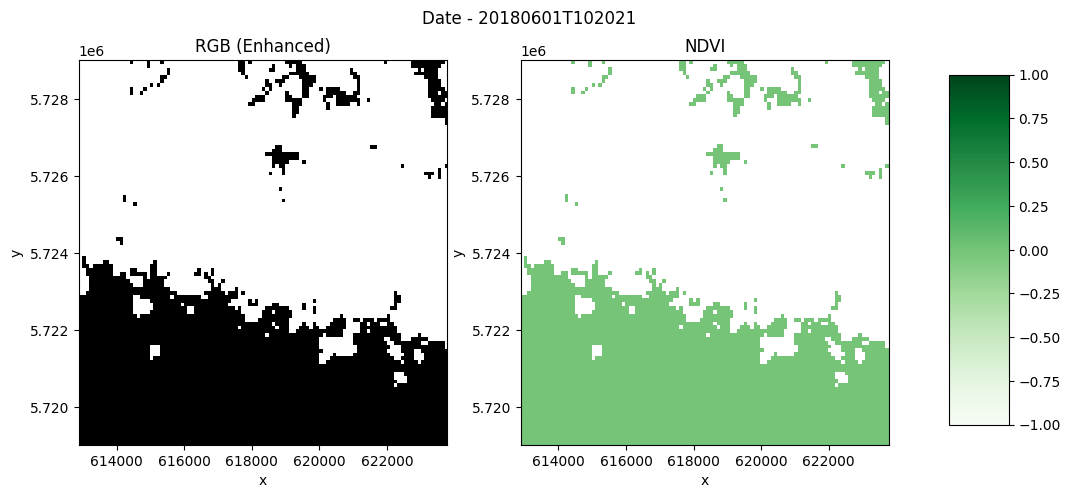

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Date - 20180601T102021\n")

# First subplot
rgb.data.plot.imshow(
    ax=ax1,
    rgb="bands",
    extent=(x_slice.start, x_slice.stop, y_slice.start, y_slice.stop),
)

ax1.set_title("RGB (Enhanced)")

# Second plot
ndvi_plot = ndvi.data.plot(ax=ax2, cmap="Greens", vmin=-1, vmax=1, add_colorbar=False)
ax2.set_title("NDVI")

# Add color bar on the right
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
fig.colorbar(ndvi_plot, cax=cbar_ax)

In [22]:
%%time
# Group by year and compute mean
# yearly_da = bbox_reproj.groupby("time.year").mean(dim="time", skipna=True)
yearly_da = (
    cloudless_ndvi.sel(x=x_slice, y=y_slice)
    .groupby("time.year")
    .mean(dim="time", skipna=True)
)
yearly_da

CPU times: total: 0 ns
Wall time: 62.1 ms


<xarray.DataArray 'data' (bands: 4, year: 1, y: 100, x: 109)> Size: 349kB
dask.array<transpose, shape=(4, 1, 100, 109), dtype=float64, chunksize=(1, 1, 78, 109), chunktype=numpy.ndarray>
Coordinates:
  * bands        (bands) <U4 64B 'b04' 'b03' 'b02' 'ndvi'
  * year         (year) int64 8B 2025
  * y            (y) float64 800B 5.729e+06 5.729e+06 ... 5.719e+06 5.719e+06
  * x            (x) float64 872B 6.129e+05 6.13e+05 ... 6.236e+05 6.237e+05
    spatial_ref  int64 8B 0
Attributes: (13)

In [24]:
def plot_rgb_ndvi(dset, year, scaling, add_offset, x_slice, y_slice):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("Date - " + str(year) + "\n")

    # First subplot
    rgb = dset.sel(bands=slice(band4, band2)) * scaling_factor_band4 + add_offset_band4
    rgb = (rgb - 0.02) / (0.35 - 0.02)  # Stretch 0.02-0.35 to 0-1
    rgb = rgb.clip(0, 1)  # Clip to valid range
    rgb.plot.imshow(
        ax=ax1,
        rgb="bands",
        extent=(x_slice.start, x_slice.stop, y_slice.start, y_slice.stop),
    )
    ax1.set_title("RGB (Enhanced)")

    # Second plot
    ndvi_plot = dset.sel(bands="ndvi").plot(
        ax=ax2, cmap="Greens", vmin=-1, vmax=1, add_colorbar=False
    )
    ax2.set_title("NDVI")

    # Add color bar on the right
    fig.subplots_adjust(right=0.8)
    cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
    fig.colorbar(ndvi_plot, cax=cbar_ax)

In [26]:
%%time
# Select year (descending y)
year = 2025  # Adjust if more years
region = yearly_da.sel(year=year, x=x_slice, y=y_slice)

region

CPU times: total: 0 ns
Wall time: 1.01 ms


<xarray.DataArray 'data' (bands: 4, y: 100, x: 109)> Size: 349kB
dask.array<getitem, shape=(4, 100, 109), dtype=float64, chunksize=(1, 78, 109), chunktype=numpy.ndarray>
Coordinates:
  * bands        (bands) <U4 64B 'b04' 'b03' 'b02' 'ndvi'
  * y            (y) float64 800B 5.729e+06 5.729e+06 ... 5.719e+06 5.719e+06
  * x            (x) float64 872B 6.129e+05 6.13e+05 ... 6.236e+05 6.237e+05
    spatial_ref  int64 8B 0
    year         int64 8B 2025
Attributes: (13)

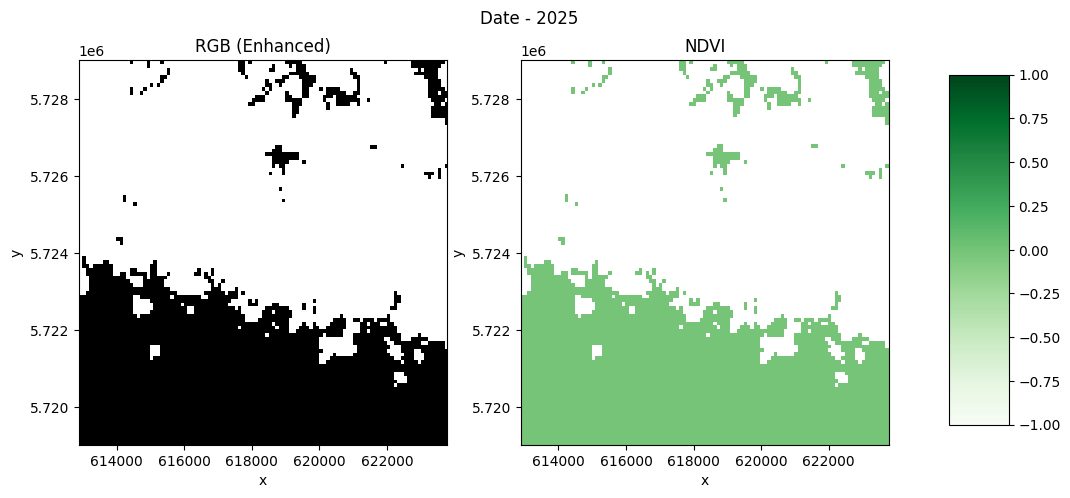

In [27]:
plot_rgb_ndvi(region, year, scaling_factor_band4, add_offset_band4, x_slice, y_slice)

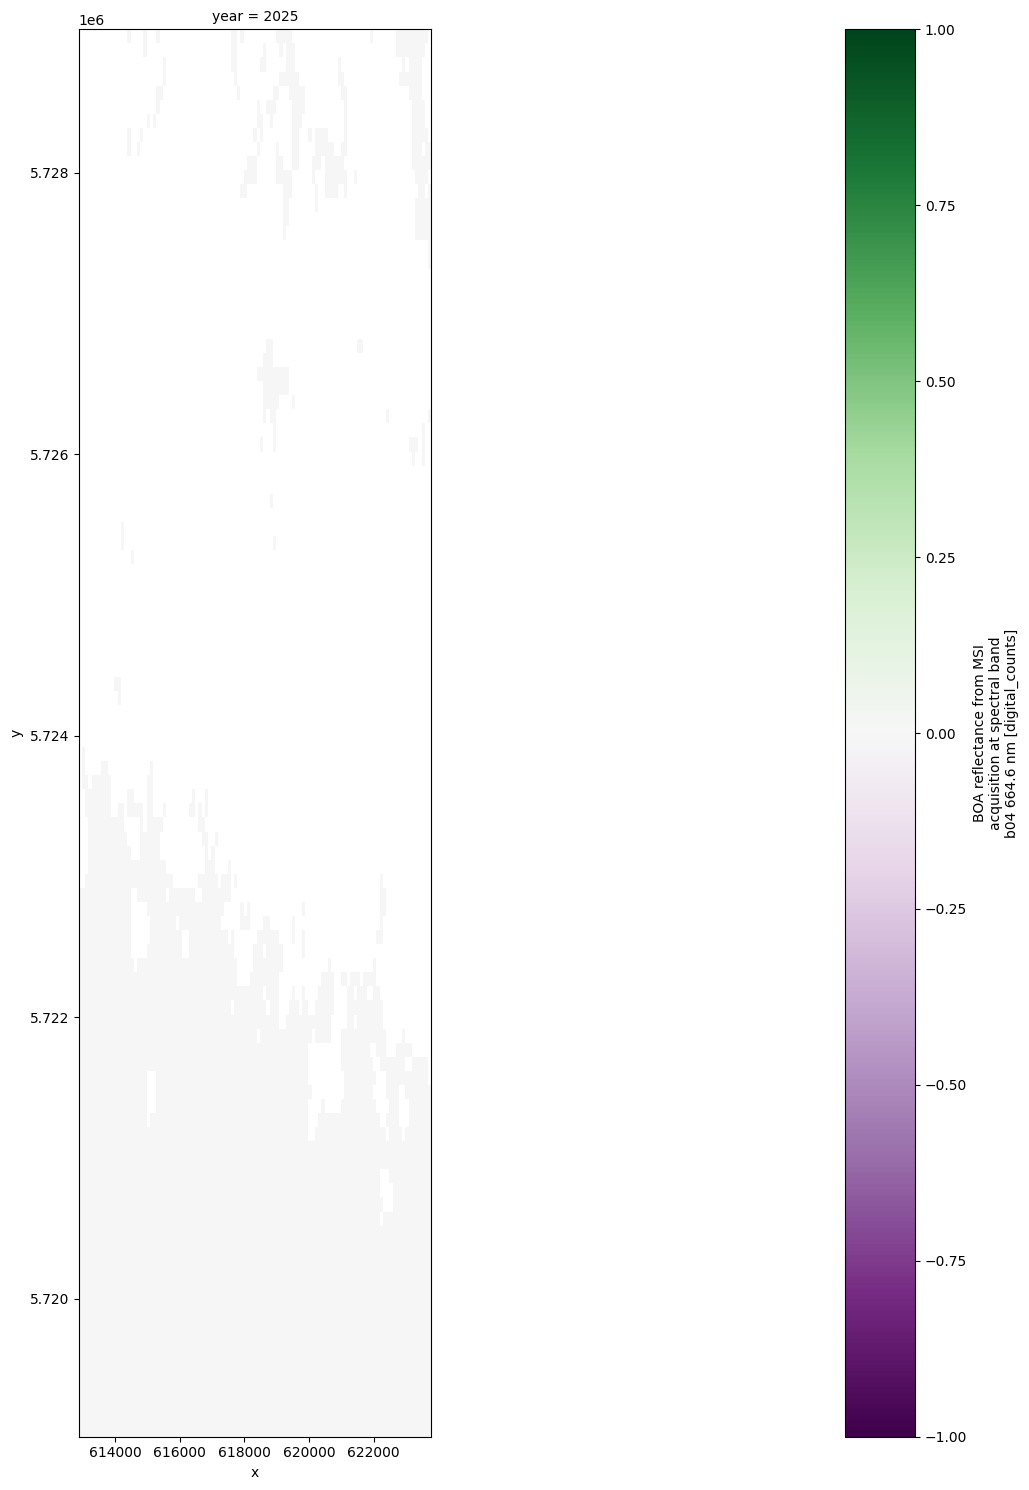

In [29]:
ndvi_yearly = yearly_da.sel(bands="ndvi", x=x_slice, y=y_slice).sel(
    year=slice(2018, 2025)
)

ndvi_yearly.plot(
    cmap="PRGn", x="x", y="y", col="year", col_wrap=2, vmin=-1, vmax=1, figsize=(10, 15)
)

In [30]:
ndvi_ds = xr.Dataset(
    {
        "NDVI": yearly_da.sel(bands="ndvi").drop_vars("bands"),
        "B04": yearly_da.sel(bands=band4).drop_vars("bands"),
        "B03": yearly_da.sel(bands=band3).drop_vars("bands"),
        "B02": yearly_da.sel(bands=band2).drop_vars("bands"),
    }
)
ndvi_ds

<xarray.Dataset> Size: 350kB
Dimensions:      (x: 109, y: 100, year: 1)
Coordinates:
  * x            (x) float64 872B 6.129e+05 6.13e+05 ... 6.236e+05 6.237e+05
  * y            (y) float64 800B 5.729e+06 5.729e+06 ... 5.719e+06 5.719e+06
  * year         (year) int64 8B 2025
    spatial_ref  int64 8B 0
Data variables:
    NDVI         (year, y, x) float64 87kB dask.array<chunksize=(1, 22, 109), meta=np.ndarray>
    B04          (year, y, x) float64 87kB dask.array<chunksize=(1, 22, 109), meta=np.ndarray>
    B03          (year, y, x) float64 87kB dask.array<chunksize=(1, 22, 109), meta=np.ndarray>
    B02          (year, y, x) float64 87kB dask.array<chunksize=(1, 22, 109), meta=np.ndarray>

In [31]:
ndvi_ds.data_vars.items()

ndvi_ds = ndvi_ds.chunk({"year": 1, "y": 50, "x": 55})
print(ndvi_ds)
print(ndvi_ds.chunks)

<xarray.Dataset> Size: 350kB
Dimensions:      (x: 109, y: 100, year: 1)
Coordinates:
  * x            (x) float64 872B 6.129e+05 6.13e+05 ... 6.236e+05 6.237e+05
  * y            (y) float64 800B 5.729e+06 5.729e+06 ... 5.719e+06 5.719e+06
  * year         (year) int64 8B 2025
    spatial_ref  int64 8B 0
Data variables:
    NDVI         (year, y, x) float64 87kB dask.array<chunksize=(1, 50, 55), meta=np.ndarray>
    B04          (year, y, x) float64 87kB dask.array<chunksize=(1, 50, 55), meta=np.ndarray>
    B03          (year, y, x) float64 87kB dask.array<chunksize=(1, 50, 55), meta=np.ndarray>
    B02          (year, y, x) float64 87kB dask.array<chunksize=(1, 50, 55), meta=np.ndarray>
Frozen({'year': (1,), 'y': (50, 50), 'x': (55, 54)})


In [ ]:
from zarr.codecs import BloscCodec

compressor = BloscCodec(cname="zstd", clevel=3, shuffle="bitshuffle", blocksize=0)

encoding = {}

for var in ndvi_ds.data_vars:
    encoding[var] = {"compressors": [compressor]}
for coord in ndvi_ds.coords:
    encoding[coord] = {"compressors": [compressor]}
ndvi_ds.to_zarr("ndvi_yearly.zarr", zarr_format=3, encoding=encoding, mode="w")

In [38]:
ndvi_ds["FOREST"] = ndvi_ds.NDVI > 0.5
ndvi_ds["FOREST"]

<xarray.DataArray 'FOREST' (year: 1, y: 100, x: 109)> Size: 11kB
dask.array<gt, shape=(1, 100, 109), dtype=bool, chunksize=(1, 50, 55), chunktype=numpy.ndarray>
Coordinates:
  * year         (year) int64 8B 2025
  * y            (y) float64 800B 5.729e+06 5.729e+06 ... 5.719e+06 5.719e+06
  * x            (x) float64 872B 6.129e+05 6.13e+05 ... 6.236e+05 6.237e+05
    spatial_ref  int64 8B 0
Attributes: (13)

In [39]:
import numpy as np


def to_km2(dataarray, resolution):
    # Calculate forest area
    return dataarray * np.prod(list(resolution)) / 1e6

resolution = (10 * factor, 10 * factor)
print("factor = ", factor, "resolution = ", resolution)
forest_pixels = ndvi_ds.sel(x=x_slice, y=y_slice).FOREST.sum(["x", "y"])
forest_area_km2 = to_km2(forest_pixels, resolution)
forest_area_km2

factor =  10 resolution =  (100, 100)


<xarray.DataArray 'FOREST' (year: 1)> Size: 8B
dask.array<truediv, shape=(1,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * year         (year) int64 8B 2025
    spatial_ref  int64 8B 0
Attributes: (13)

In [40]:
forest_area_km2.load()

forest_area_km2.plot()

plt.title("Forest Cover")
plt.ylabel("Forest Cover [km²]")
plt.ylim(0);

TypeError: No numeric data to plot.

In [41]:
forest_area_km2

<xarray.DataArray 'FOREST' (year: 1)> Size: 8B
array([0.])
Coordinates:
  * year         (year) int64 8B 2025
    spatial_ref  int64 8B 0
Attributes: (13)